# SIR, birth and death 
{func}`.SIR_Birth_Death`

Here we consider an SIR model in which individuals may be removed by death from each compartment at a uniform rate per person, $\gamma$.
The population is replenished via births into the susceptible compartment at the same rate, thus conserving the total population by design.
For deterministic evolution, the population size remains constant whereas for stochastic evolution, the size fluctuates around this value.
The equations are as follows:

$$\begin{aligned}
\frac{\mathrm{d}S}{\mathrm{d}t} &= \mu N - \frac{\beta SI}{N} - \mu S \\
\frac{\mathrm{d}I}{\mathrm{d}t} &= \frac{\beta SI}{N} - \gamma I - \mu I \\
\frac{\mathrm{d}R}{\mathrm{d}t} &= \gamma I - \mu R
\end{aligned}$$

As an example, we study stochastic evolution of this system with measles-like parameters in 3 differently sized populations.
This provides a demonstration of threshold population sizes in order to support endemic circulation of certain pathogens.

In [ ]:
from pygom import common_models
import matplotlib.pyplot as plt
import numpy as np
import math

#####################
# Set up PyGOM object
#####################

# Parameters
mu = 0.01/365    # birth/death rate 1% per year
gamma = 1/20 
R0 = 15
beta = R0*gamma

model = common_models.SIR_Birth_Death(
    {
        'beta':beta,
        'gamma':gamma,
        'mu':mu
    }
)

# Time range and increments
tmax = 365*10                           # maximum time over which to run solver
dt = 1                                  # timestep
t = np.arange(0, tmax, dt)              # times at which solution will be evaluated

# Initial conditions (endemic equilibrium derived from stationary point)
def sir_bd_endemic_eq(mu, beta, gamma, n_pop):
    s0 = math.floor( (gamma + mu) * n_pop / beta)
    i0 = math.floor( mu * (n_pop - s0) * n_pop / (beta * s0))
    r0 = n_pop - (s0 + i0)
    return np.array([s0, i0, r0, n_pop], dtype=np.int64)


n_sim = 10

# Simulate with increasing population sizes
solutions = []
n_pops = [1e4, 1e5, 1e6]
for n_pop in n_pops:
    x0 = sir_bd_endemic_eq(mu, beta, gamma, n_pop)
    model.initial_values = (x0, t[0])

    solution = model.solve_stochastic(
        t=t,
        method="fixed_tau",
        tau=0.5,
        iteration=n_sim,
        seed=1
    )

    solutions.append(solution)

10000.0
100000.0
1000000.0


Plotting the results, we see that for populations of sizes 10,000 and 100,000, the infected population is critically close to zero, such that stochastic fluctuations eventually lead to disease extinction.
This is of course signified by the infected class reaching zero, but also by the recovered and susceptible classes undergoing stable linear growth due to population turnover.
When the population size is 1,000,000, we see that the infected subset, of typical size 500, is able to persist for the full 10 years of the simulation.

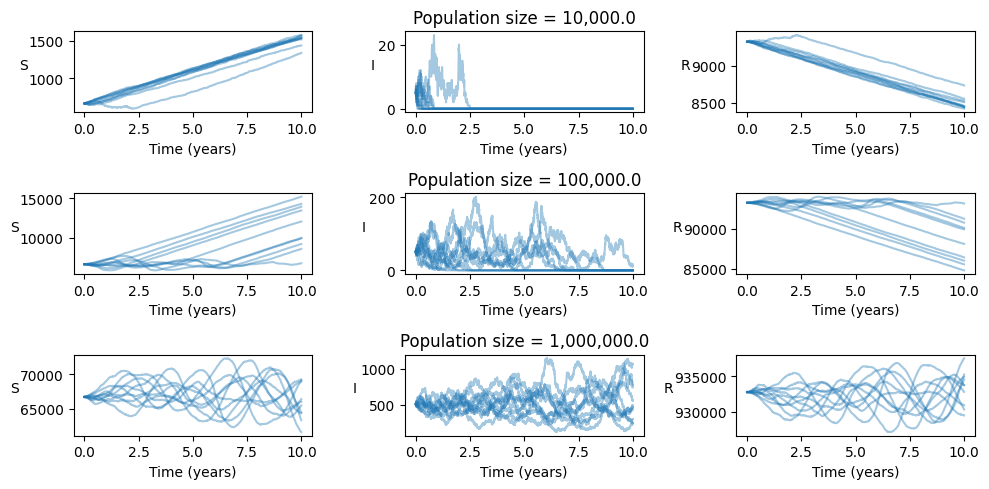

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(10, 5))

state_names = model.state_list

for pop, solution in enumerate(solutions):
    axes[pop][1].set_title(f"Population size = {n_pops[pop]:,}")
    for state in range(3):
        for sim in range(n_sim):
            axes[pop][state].plot(t/365, solution[sim].result.y[:, state], alpha=0.4, color="C0")
            axes[pop][state].set_xlabel("Time (years)")
            axes[pop][state].set_ylabel(state_names[state], rotation=0)

plt.tight_layout()
plt.show()